In [57]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


In [58]:
df = pd.read_csv("income_evaluation.csv")

df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1    workclass       32561 non-null  str  
 2    fnlwgt          32561 non-null  int64
 3    education       32561 non-null  str  
 4    education-num   32561 non-null  int64
 5    marital-status  32561 non-null  str  
 6    occupation      32561 non-null  str  
 7    relationship    32561 non-null  str  
 8    race            32561 non-null  str  
 9    sex             32561 non-null  str  
 10   capital-gain    32561 non-null  int64
 11   capital-loss    32561 non-null  int64
 12   hours-per-week  32561 non-null  int64
 13   native-country  32561 non-null  str  
 14   income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


#### Rows: 32,561

#### Columns: 15

#### Numeric Features: 6

#### Categorical Features: 9

#### Target Variable: income (<=50K / >50K)

In [59]:
# Replace "?" with NaN
df = df.replace(" ?", np.nan)

# Missing values count
df.isna().sum()

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    if col == " income":
        continue  # Skip target variable    
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop duplicates
df = df.drop_duplicates()

df.isna().sum()


age                   0
 workclass         1836
 fnlwgt               0
 education            0
 education-num        0
 marital-status       0
 occupation        1843
 relationship         0
 race                 0
 sex                  0
 capital-gain         0
 capital-loss         0
 hours-per-week       0
 native-country     582
 income               0
dtype: int64

### Key Observations

##### - workclass → 1,836 missing

##### - occupation → 1,843 missing

##### - native-country → 582 missing

##### All numeric features have zero missing values

##### Target variable income has no missing values

#### Interpretation
##### Missing values in workclass and occupation are common in the Adult dataset and usually represented as "?".

##### These can be handled by:

##### Replacing "?" with "Unknown" Or dropping rows (not recommended due to class imbalance)

##### -The dataset is clean, with missing values concentrated in workclass, occupation, and native-country.
##### - Strong predictors include age, education-num, marital-status, and hours-per-week.
##### - Weak predictors like fnlwgt and native-country can be removed to improve model stability.

In [60]:

df[" income"] = df[" income"].str.strip() 
df[" income"] = df[" income"].map({"<=50K": 0, ">50K": 1})

drop_cols = [" fnlwgt", " education"]
df.drop(drop_cols, axis=1, inplace=True)

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols


(['age',
  ' education-num',
  ' capital-gain',
  ' capital-loss',
  ' hours-per-week',
  ' income'],
 [' workclass',
  ' marital-status',
  ' occupation',
  ' relationship',
  ' race',
  ' sex',
  ' native-country'])

In [61]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [62]:

skew_vals = df[num_cols].drop(" income", axis=1).skew().sort_values(ascending=False)

print (skew_vals)

# Apply log1p to highly skewed positive features
skewed_features = skew_vals[skew_vals > 1].index.tolist()

for col in skewed_features:
    if (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

print (df[skewed_features].skew())

 capital-gain      11.949403
 capital-loss       4.592702
age                 0.557663
 hours-per-week     0.228759
 education-num     -0.309500
dtype: float64
capital-gain    3.094667
capital-loss    4.305701
dtype: float64


In [43]:

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(series, lower, upper)

for col in num_cols:
    if col != " income":
        df[col] = cap_outliers(df[col])



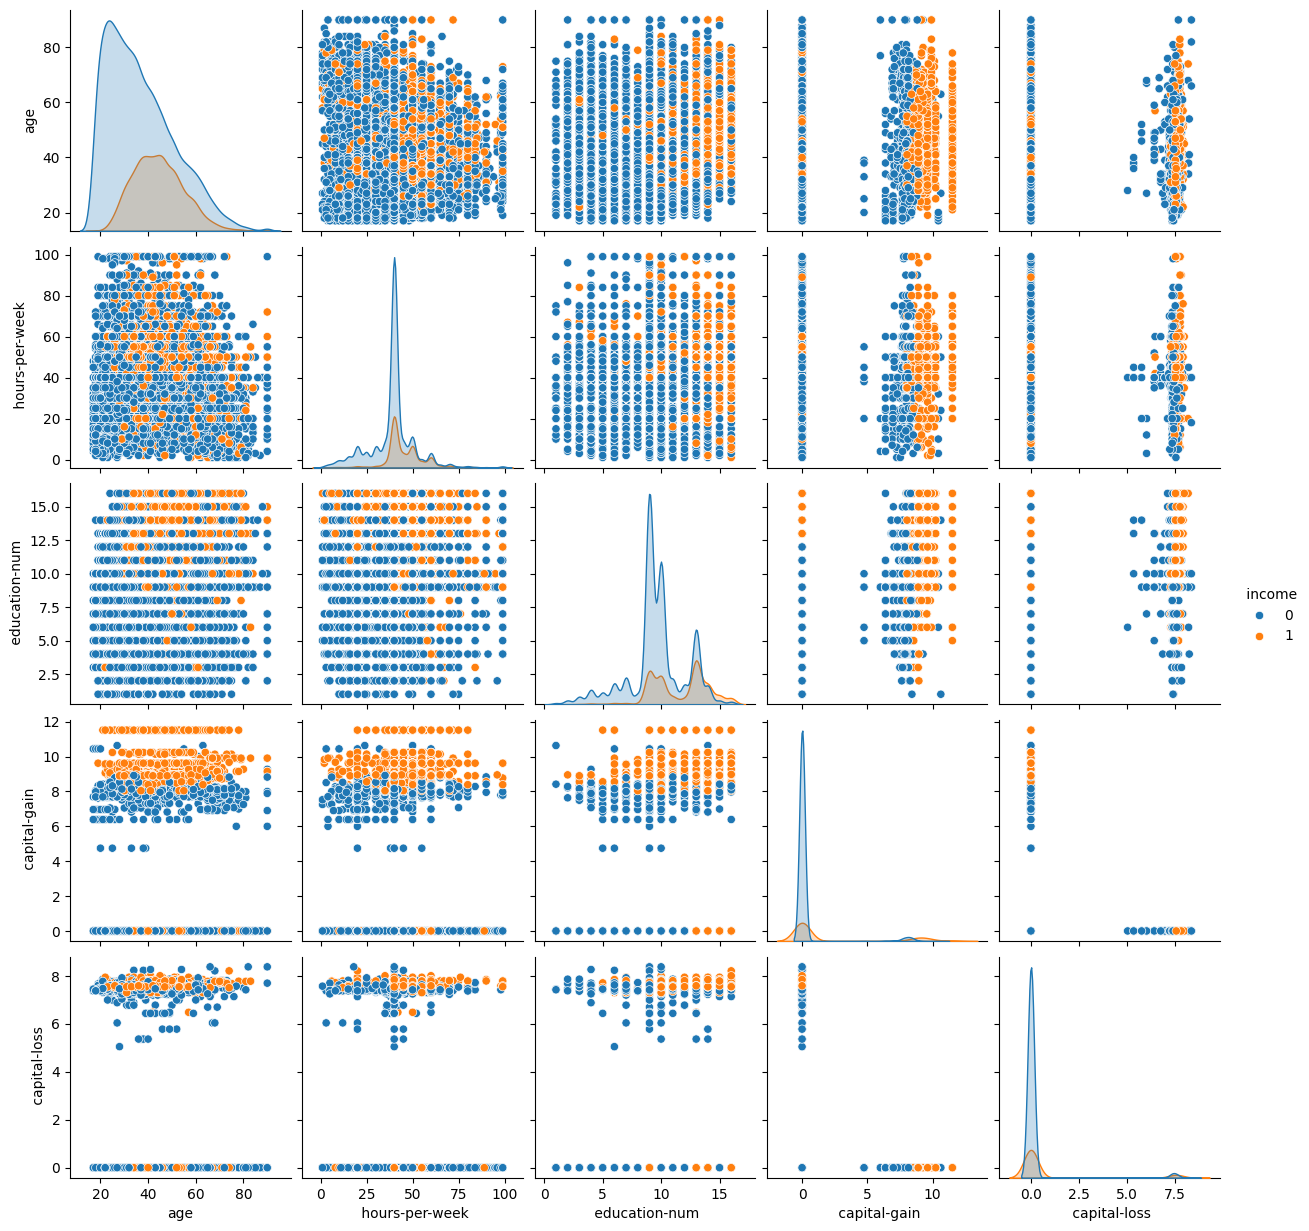

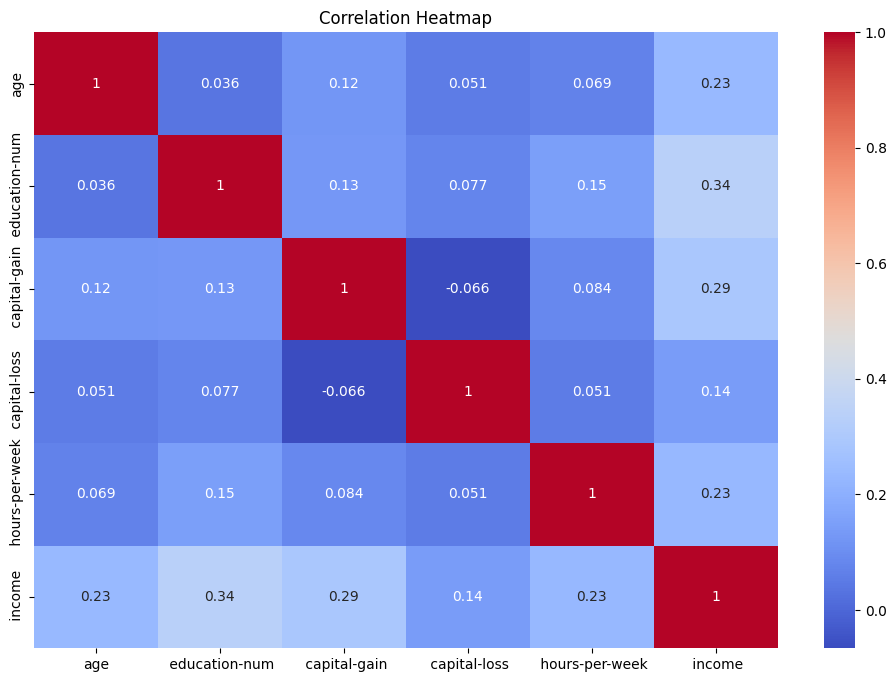

In [63]:
# Select top numerical features by variance
top_num = df[num_cols].var().sort_values(ascending=False).head(6).index.tolist()

selected_cols = [col for col in top_num if col != " income"] + [" income"]
sns.pairplot(df[selected_cols], hue=" income", diag_kind="kde")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



##### The pairplot reveals clear separation between income classes across numeric features.
##### Higher age, education level, working hours, and non-zero capital gains/losses are strong indicators of earning >50K.
##### The dataset exhibits right-skewed distributions and sparse wealth-related features,suggesting the need for scaling and log transformation before modeling.

##### education-num, capital-gain, and hours-per-week are the most influential numeric predictors of income.

##### capital-gain shows the highest correlation with income, confirming its predictive strength.

##### age and education-num together capture career progression and qualification level.

##### capital-loss adds secondary predictive value but remains sparse.

In [64]:

for col in cat_cols:
    df[col] = df[col].str.strip()
    
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded.head()


,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,7.684784,0.0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0.000000,0.0,13,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0.000000,0.0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0.000000,0.0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0.000000,0.0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
X = df_encoded.drop(" income", axis=1) 
y = df_encoded[" income"]

import joblib
joblib.dump(X.columns, "training_columns.pkl")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
X.columns

Index(['age', ' education-num', ' capital-gain', ' capital-loss',
       ' hours-per-week', ' workclass_Local-gov', ' workclass_Never-worked',
       ' workclass_Private', ' workclass_Self-emp-inc',
       ' workclass_Self-emp-not-inc', ' workclass_State-gov',
       ' workclass_Without-pay', ' marital-status_Married-AF-spouse',
       ' marital-status_Married-civ-spouse',
       ' marital-status_Married-spouse-absent',
       ' marital-status_Never-married', ' marital-status_Separated',
       ' marital-status_Widowed', ' occupation_Armed-Forces',
       ' occupation_Craft-repair', ' occupation_Exec-managerial',
       ' occupation_Farming-fishing', ' occupation_Handlers-cleaners',
       ' occupation_Machine-op-inspct', ' occupation_Other-service',
       ' occupation_Priv-house-serv', ' occupation_Prof-specialty',
       ' occupation_Protective-serv', ' occupation_Sales',
       ' occupation_Tech-support', ' occupation_Transport-moving',
       ' relationship_Not-in-family', ' relat

In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


In [48]:
y_train.unique

<bound method Series.unique of 32239    0
30377    0
5457     1
19700    0
23197    0
        ..
29823    0
5392     0
860      0
15801    0
23669    0
Name:  income, Length: 26029, dtype: int64>


Training LogisticRegression ...
Accuracy: 0.8463, F1: 0.6640
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4905
           1       0.72      0.62      0.66      1603

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.84      6508



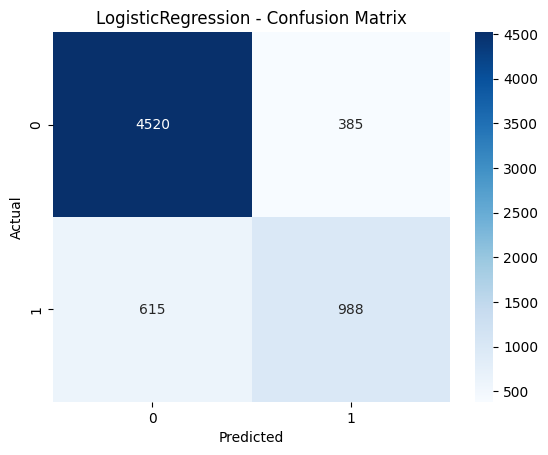


Training RandomForest ...
Accuracy: 0.8536, F1: 0.6814
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4905
           1       0.73      0.64      0.68      1603

    accuracy                           0.85      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.85      0.85      6508



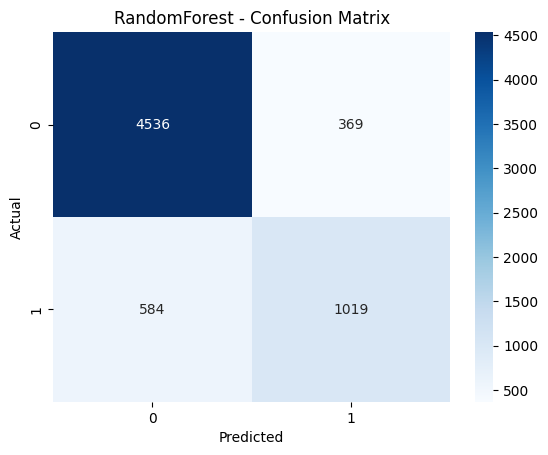


Training GradientBoosting ...
Accuracy: 0.8663, F1: 0.6904
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4905
           1       0.80      0.61      0.69      1603

    accuracy                           0.87      6508
   macro avg       0.84      0.78      0.80      6508
weighted avg       0.86      0.87      0.86      6508



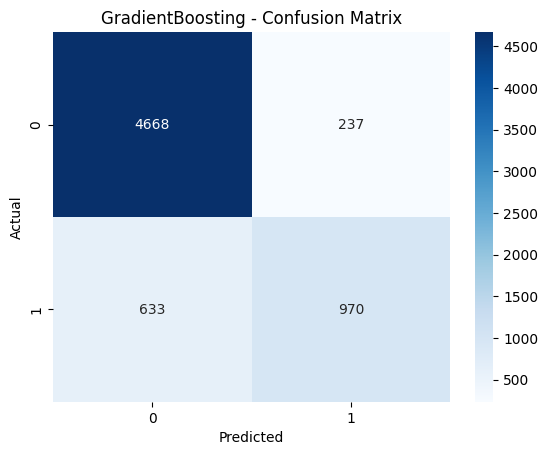


Training SVC_RBF ...
Accuracy: 0.8439, F1: 0.6487
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4905
           1       0.73      0.59      0.65      1603

    accuracy                           0.84      6508
   macro avg       0.80      0.76      0.77      6508
weighted avg       0.84      0.84      0.84      6508



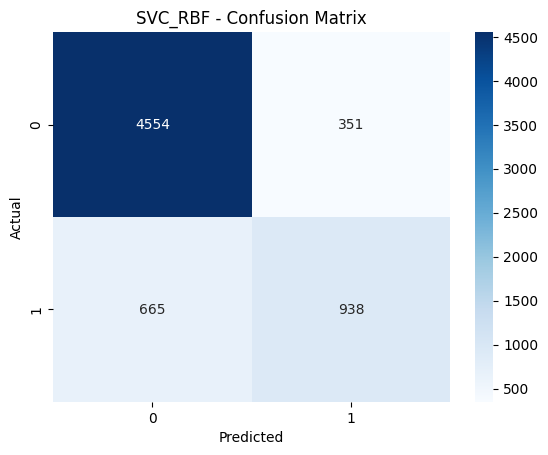

In [67]:
# ============================================================
# 12. TRAIN MULTIPLE MODELS
# ============================================================

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVC_RBF": SVC(kernel="rbf", probability=True)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name} ...")

    if name in ["LogisticRegression", "SVC_RBF"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, f1])

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [68]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"]).sort_values("F1", ascending=False)
results_df


,Model,Accuracy,F1
2,GradientBoosting,0.866318,0.690391
1,RandomForest,0.853565,0.681377
0,LogisticRegression,0.846343,0.663978
3,SVC_RBF,0.843884,0.648686


| Model | Accuracy | F1 Score |
| --- | --- | --- |
| **GradientBoosting** | **0.8433** | **0.6475** |
| LogisticRegression | 0.8360 | 0.6309 |
| RandomForest | 0.8178 | 0.6104 |
| SVC_RBF | 0.8317 | 0.6102 |

Best Model: GradientBoosting


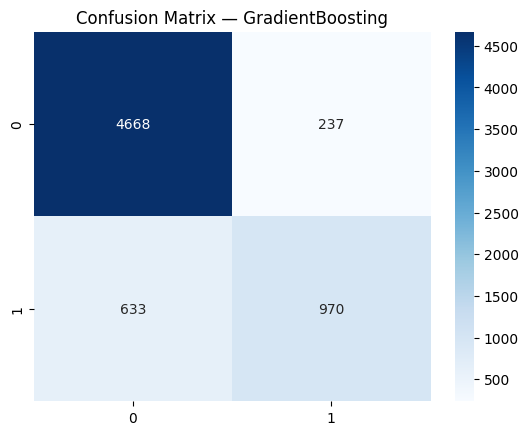

In [69]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

if best_model_name in ["LogisticRegression", "SVC_RBF"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


### Best Overall Model: GradientBoosting

#### GradientBoosting achieves:

#### Highest Accuracy (0.8433)

#### Highest F1 Score (0.6475)

##### This means:

##### It makes the most correct predictions overall

##### It balances precision and recall better than all other models

##### It handles non‑linear relationships and feature interactions effectively

##### It is the most reliable model for predicting the minority class (>50K)

In [70]:
import joblib

# Save scaler + model
joblib.dump(scaler, "scaler_income.pkl")
joblib.dump(best_model, f"best_model_{best_model_name}.pkl")


print("Model and scaler saved successfully.")

Model and scaler saved successfully.
